In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import numpy as np
from scipy.stats import gmean

In [2]:
# Read in data
cd8_t = pd.read_csv('../data/all_cd8_t_cells_patient_updated_patient_updated.csv')

In [3]:
# Read in clustering results
df_clust = pd.read_excel('../data/2024_06_25_Annotations.xlsx')
df_clust_dict = dict(zip(df_clust['FlowSOM_Cluster'], df_clust['Annotation']))
df_clust_dict
to_keep = [x for x, y in df_clust_dict.items() if (y == 'CD56pos_GzmBpos') | (y == 'CD56neg_GzmBpos')]
               

In [4]:
# Select the cytotoxic cells
print(cd8_t.shape)
cd8_t = cd8_t.loc[cd8_t['FlowSOM_metacluster'].isin(to_keep), :]
cd8_t['cell_type'] = cd8_t['FlowSOM_metacluster'].map(df_clust_dict)
print(cd8_t.shape)

(2343096, 68)
(1529349, 69)


In [5]:
cd8_t['FileName']

0           P08_C1_D8_T_Cell_Panel
1           P08_C1_D8_T_Cell_Panel
3           P08_C1_D8_T_Cell_Panel
4           P08_C1_D8_T_Cell_Panel
6           P08_C1_D8_T_Cell_Panel
                    ...           
2343091    Control_11_T_Cell_Panel
2343092    Control_11_T_Cell_Panel
2343093    Control_11_T_Cell_Panel
2343094    Control_11_T_Cell_Panel
2343095    Control_11_T_Cell_Panel
Name: FileName, Length: 1529349, dtype: object

In [6]:
# Delete spare progression sample (there was a second later measurement which was associated with progression)
# Delete sample 61290 006 as the patient went off trial due to participant preference

cd8_t = cd8_t.loc[cd8_t['FileName'] != 'P02_SPD_T_Cell_Panel',:]
cd8_t = cd8_t.loc[~cd8_t['FileName'].str.contains('P26'),:]
cd8_t['FileName'] = cd8_t['FileName'].str.replace('P02_SPD_2_T_Cell_Panel', 'P02_SPD_T_Cell_Panel')

# Delete the following samples as they have only a single measurement
cd8_t = cd8_t.loc[~cd8_t['FileName'].str.contains('P27'),:]
cd8_t = cd8_t.loc[~cd8_t['FileName'].str.contains('P15'),:]
cd8_t.head()

,Unnamed: 0.1,Unnamed: 0,209Bi_CD45,Center,164Dy,166Er_CD34,Event_length,157Gd,113In_CD45,191Ir_DNA1,...,169Tm_CD25_asinh_coarseAlign_fineAlign,171Yb_Granzyme_B_asinh_coarseAlign_fineAlign,172Yb_CD38_asinh_coarseAlign_fineAlign,173Yb_CD14_asinh_coarseAlign_fineAlign,174Yb_HLA-DR_asinh_coarseAlign_fineAlign,176Yb_CD56_asinh_coarseAlign_fineAlign,Alignment_MC_fineAlign,FlowSOM_cluster,FlowSOM_metacluster,cell_type
0,0,1,0.000000,703.693,0.0,0.0,17,0.000000,0.0,218.307,...,0.011151,5.832982,2.280988,0.01453,0.647175,0.054384,7,70,22,CD56neg_GzmBpos
1,1,2,0.050212,791.971,0.0,0.0,20,0.000000,0.0,156.895,...,0.011151,3.614947,1.015876,0.01453,0.073580,0.054384,7,90,6,CD56neg_GzmBpos
3,3,4,0.000000,794.320,0.0,0.0,17,0.927911,0.0,149.295,...,0.011151,3.379903,0.456208,0.01453,0.788640,0.054384,7,83,24,CD56neg_GzmBpos
4,4,5,0.000000,652.678,0.0,0.0,16,0.000000,0.0,223.637,...,0.011151,3.800616,0.642546,0.01453,0.835205,0.054384,7,149,32,CD56neg_GzmBpos
6,6,7,3.061160,758.698,0.0,0.0,16,0.000000,0.0,131.881,...,0.011151,5.270374,0.308231,0.01453,0.645065,1.424618,7,136,29,CD56neg_GzmBpos


In [7]:
# Rename columns to permit easier plotting
cd8_t.columns = [col.split('_')[1] if '_' in col else col for col in cd8_t.columns]
cd8_t.columns = cd8_t.columns.str.replace('Granzyme', 'GzmB')
cd8_t.columns = cd8_t.columns.str.replace('CD335', 'NKp46')
cd8_t.columns = cd8_t.columns.str.replace('CD279', 'PD1')


In [8]:
# Set NA values to 0 so that I don't get NA values in my df
columns_to_modify = ['NKp46', 'FoxP3', 'CD183', 'CD33',
       'Ki67', 'CD3', 'CD39', 'CD314', 'PD1', 'CD194', 'CD197', 'CD127',
       'CD11c', 'CD57', 'Perforin', 'CD19', 'CD45RA', 'CD69', 'CD4', 'CD8a',
       'CD16', 'KLRG1', 'CD45RO', 'Tim3', 'CD159c', 'CD25', 'GzmB',
       'CD38', 'CD14', 'HLA-DR', 'CD56']  # Replace with your column names
cd8_t[columns_to_modify] = cd8_t[columns_to_modify].clip(lower=0)

In [9]:
# Create a dataframe which shows the geometric mean of the 
result_df = []

# Molecules we're interested in
molecules = cd8_t.loc[:, 'NKp46':'CD56'].columns.tolist()

# Group by FileName and CellType
for (file, cell), group in cd8_t.groupby(['FileName', 'type']):
    for molecule in molecules:
        # Extract values and add 0.01 to avoid zeros
        values = group[molecule] + 0.01
        # Calculate geometric mean
        geo_mean = gmean(values)
        
        # Append result as a row
        result_df.append({
            'FileName': file,
            'CellType': cell,
            'Molecule': molecule,
            'Expression': geo_mean
        })

# Convert list of dictionaries to DataFrame
result_df = pd.DataFrame(result_df)

In [10]:
# Reshape the dataframe from long to wide
pivoted_df = result_df.pivot_table(
    index=['FileName', 'CellType'],
    columns='Molecule',
    values='Expression',
    aggfunc='mean'  # If there are duplicates, take the first value
)
pivoted_df = pivoted_df.reset_index()

In [11]:
# Read in a dictionary which details the color of each cluster
color = pd.read_excel('../data/2025_12_15_Cell_color_table.xlsx')
color = color.iloc[7: , :]
color_dict = dict(zip(color['Cell_type'], color['Color']))
color_dict

{'CD56neg_GzmBpos': '#3498DBFF', 'CD56pos_GzmBpos': '#D35400FF'}

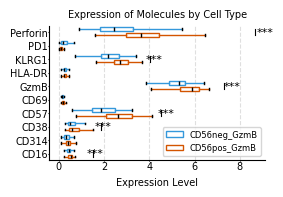

<Figure size 640x480 with 0 Axes>

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

plt.rcParams['svg.fonttype'] = 'none' # export font as editable text
plt.rcParams['pdf.fonttype'] = 'truetype' # export font as editable text

# Assuming your dataframe is called pivoted_df
# Get list of molecules to plot
molecules = [ 'CD16', 'CD314',
       'CD38', 'CD57', 'CD69',
       'GzmB', 'HLA-DR', 'KLRG1', 
       'PD1', 'Perforin']

# Separate data by cell type
cd56neg = pivoted_df[pivoted_df['CellType'] == 'CD56neg_GzmBpos']
cd56pos = pivoted_df[pivoted_df['CellType'] == 'CD56pos_GzmBpos']

# Create figure and axis - swapped dimensions for horizontal layout
fig, ax = plt.subplots(figsize=(3, 3 * (18/26)))

# Set positions for boxplots - now vertical positions
positions = np.arange(1, 2*len(molecules)+1, 2)  # [1, 3, 5, ...]

# Perform t-tests and plot boxplots
for i, molecule in enumerate(molecules):
    # Create boxplot positions
    pos_neg = positions[i] + 0.45
    pos_pos = positions[i] - 0.45
    
    # Check if mean of at least one group is greater than 0.5
    neg_mean = cd56neg[molecule].mean()
    pos_mean = cd56pos[molecule].mean()
    show_significance = (neg_mean > 0.5 or pos_mean > 0.5)
    
    # Perform paired t-test only if the threshold is met
    if show_significance:
        # Assuming you have a common index or patient ID to match the pairs
        paired_data = pd.merge(
            cd56neg[['FileName', molecule]], 
            cd56pos[['FileName', molecule]], 
            on='FileName', 
            suffixes=('_neg', '_pos')
        )
        
        if len(paired_data) > 0:
            t_stat, p_value = stats.ttest_rel(paired_data[f'{molecule}_neg'], 
                                             paired_data[f'{molecule}_pos'])
        else:
            # Fallback to unpaired test if pairing isn't possible
            t_stat, p_value = stats.ttest_ind(cd56neg[molecule], cd56pos[molecule], 
                                             equal_var=False)  # Welch's t-test
        
        # Determine significance stars
        if p_value < 0.0001:
            stars = '***'
        elif p_value < 0.01:
            stars = '**'
        elif p_value < 0.05:
            stars = '*'
        else:
            stars = 'ns'
    
    # Create boxprops for horizontal boxplots
    cd56neg_boxprops = dict(facecolor='white', edgecolor= color_dict['CD56neg_GzmBpos'], alpha=1)
    cd56pos_boxprops  = dict(facecolor='white', edgecolor =color_dict['CD56pos_GzmBpos'], alpha=1)
    cd56neg_whiskerprops = dict(color=color_dict['CD56neg_GzmBpos'])
    cd56pos_whiskerprops = dict(color=color_dict['CD56pos_GzmBpos'])
    medianprops = dict(color='black')
    
    # Plot horizontal boxplots
    bp_neg = ax.boxplot(cd56neg[molecule], positions=[pos_neg], widths=0.55, 
                        patch_artist=True, boxprops=cd56neg_boxprops, whiskerprops=cd56neg_whiskerprops,
                        medianprops=medianprops, showfliers=False, vert=False)
    
    bp_pos = ax.boxplot(cd56pos[molecule], positions=[pos_pos], widths=0.55,
                       patch_artist=True, boxprops=cd56pos_boxprops, whiskerprops=cd56pos_whiskerprops,
                       medianprops=medianprops, showfliers=False, vert=False)
    
    # Add individual data points with jitter (now horizontal jitter)
    y_jitter_neg = np.random.normal(pos_neg, 0.05, size=len(cd56neg))
    y_jitter_pos = np.random.normal(pos_pos, 0.05, size=len(cd56pos))
    
    # Add significance stars only if the threshold is met
    if show_significance:
        x_max = max(cd56neg[molecule].max(), cd56pos[molecule].max())
        x_pos = x_max * 1.1  # Position the stars slightly to the right of the maximum value
        
        # Draw a line connecting the two boxes (now vertical line)
        ax.plot([x_pos, x_pos], [pos_neg, pos_pos], color='black', linewidth=0.8)
        
        # Add the stars
        ax.text(x_pos*1.05, (pos_neg + pos_pos)/2, stars, 
                horizontalalignment='center', verticalalignment='center', fontsize=8)

# Add labels and title - swapped x and y
ax.set_ylabel('', fontsize=7)
ax.set_xlabel('Expression Level', fontsize=7)
ax.set_title('Expression of Molecules by Cell Type', fontsize=7)

# Set y-ticks at the center of each molecule's group
ax.set_yticks(positions)
ax.set_yticklabels(molecules, fontsize=7)

ax.tick_params(length = 1, pad = 0.1, labelsize = 7)

# Add legend with custom handles
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='white', edgecolor = color_dict['CD56neg_GzmBpos'], label='CD56neg_GzmB'),
    Patch(facecolor='white', edgecolor = color_dict['CD56pos_GzmBpos'], label='CD56pos_GzmB')
]
ax.legend(handles=legend_elements, fontsize=6)

# Add grid lines - now vertical grid lines
ax.grid(True, linestyle='--', alpha=0.4, axis='x')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Adjust layout and allow for the stars to the right of the plot
plt.tight_layout()
plt.subplots_adjust(right=0.9)  # Give more room at the right for the stars
plt.show()
plt.tight_layout()
#fig.savefig('../results/comparison_of_cd56pos_cd56neg_gzmb.pdf')